# Romania TSP using Euclidean distances: HC, SA and GA

This notebook solves a **Travelling Salesman Problem (TSP)** using the coordinates of 20 Romania cities.

It treats the problem as a complete Euclidean TSP:

- Each city is represented by an `(x, y)` coordinate.
- The distance between two cities is the straight-line Euclidean distance.
- A solution is a permutation of all cities.
- Each city appears exactly once in the route.
- The route returns to the starting city at the end.

Algorithms included:

1. **Hill Climbing (HC)** with random restarts
2. **Simulated Annealing (SA)**
3. **Genetic Algorithm (GA)**

## Import libraries

In [ ]:
import random
import math
import statistics
import matplotlib.pyplot as plt

random.seed(7)

## Define the Romania city coordinates

The coordinates are used only to calculate Euclidean distance and to draw the route. The TSP graph is treated as a complete graph, meaning every pair of cities has a direct Euclidean distance.


In [2]:
locations = {
    'Arad': (91, 492),
    'Bucharest': (400, 327),
    'Craiova': (253, 288),
    'Drobeta': (165, 299),
    'Eforie': (562, 293),
    'Fagaras': (305, 449),
    'Giurgiu': (375, 270),
    'Hirsova': (534, 350),
    'Iasi': (473, 506),
    'Lugoj': (165, 379),
    'Mehadia': (168, 339),
    'Neamt': (406, 537),
    'Oradea': (131, 571),
    'Pitesti': (320, 368),
    'Rimnicu Vilcea': (233, 410),
    'Sibiu': (207, 457),
    'Timisoara': (94, 410),
    'Urziceni': (456, 350),
    'Vaslui': (509, 444),
    'Zerind': (108, 531),
}

cities = list(locations.keys())
start_city = 'Arad'

print('Number of cities:', len(cities))
print('Start city:', start_city)

Number of cities: 20
Start city: Arad



## Euclidean distance function

For a correct Euclidean TSP formulation, the distance between two cities is calculated directly from their coordinates:

$$
	\text{distance}(A,B)=\sqrt{(x_A-x_B)^2+(y_A-y_B)^2}
$$
Where:
- $x_A$ and $y_A$ are the coordinates of city $A$.
- $x_B$ and $y_B$ are the coordinates of city $B$.

No intermediate cities are used when calculating the distance between a pair of cities.



In [3]:
def euclidean_distance(city1, city2):
    x1, y1 = locations[city1]
    x2, y2 = locations[city2]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

In [4]:
# Precompute all pairwise Euclidean distances for efficient lookup (simple version)

# Create an empty dictionary to store all pairwise distances
distance_matrix = {}

# For each starting city
for city1 in cities:

    # Create a dictionary for distances from city1 to other cities
    distance_matrix[city1] = {}

    # For each destination city
    for city2 in cities:

        # Compute and store the Euclidean distance
        distance_matrix[city1][city2] = euclidean_distance(city1, city2)

print('Euclidean distance from Arad to Bucharest:', round(distance_matrix['Arad']['Bucharest'], 2))

Euclidean distance from Arad to Bucharest: 350.29


## TSP route representation and objective function

A route is represented as a list of city names. The first city is fixed as `start_city`.

Example:

```python
['Arad', 'Sibiu', 'Fagaras', ..., 'Zerind']
```

The objective function calculates the full round-trip distance, including returning from the last city to the start city.


In [5]:
def route_distance(route):
    total = 0
    for i in range(len(route) - 1):
        total += distance_matrix[route[i]][route[i + 1]]
    total += distance_matrix[route[-1]][route[0]]
    return total

### Solution validation

*   A solution is a permutation of all cities.
*   Each city appears exactly once in the route.
*   The route returns to the starting city at the end.

In [6]:
def is_valid_tsp_route(route):
    return len(route) == len(cities) and len(set(route)) == len(cities) and route[0] == start_city

validation_function = is_valid_tsp_route

### Neighbouring function

In [7]:
def swap_neighbour(route):
    neighbour = route.copy()
    i, j = random.sample(range(1, len(neighbour)), 2)
    neighbour[i], neighbour[j] = neighbour[j], neighbour[i]
    return neighbour

### Random route

In [8]:
def make_random_route(start=start_city):
    other_cities = [city for city in cities if city != start]
    random.shuffle(other_cities)
    return [start] + other_cities

### Sample route

In [9]:
sample_route = make_random_route()
print('Sample route:', sample_route)
print('Is valid TSP route?', is_valid_tsp_route(sample_route))
print('Sample route distance:', round(route_distance(sample_route), 2))

Sample route: ['Arad', 'Oradea', 'Drobeta', 'Zerind', 'Vaslui', 'Iasi', 'Hirsova', 'Urziceni', 'Eforie', 'Bucharest', 'Mehadia', 'Giurgiu', 'Sibiu', 'Lugoj', 'Rimnicu Vilcea', 'Timisoara', 'Craiova', 'Pitesti', 'Fagaras', 'Neamt']
Is valid TSP route? True
Sample route distance: 3458.48


## Visualise city locations

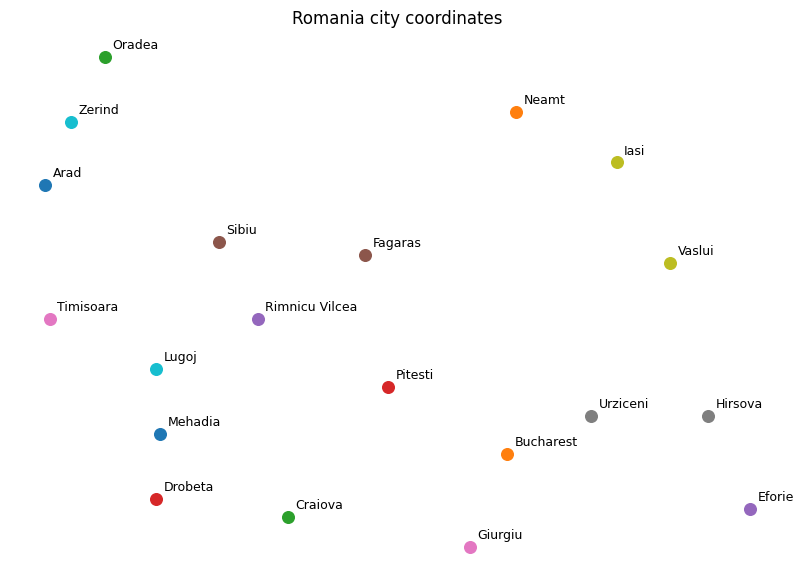

In [10]:
def plot_cities(title='Romania city coordinates'):
    plt.figure(figsize=(10, 7))
    for city, (x, y) in locations.items():
        plt.scatter([x], [y], s=70)
        plt.text(x + 5, y + 5, city, fontsize=9)
    plt.title(title)
    plt.axis('off')

plot_cities()

In [11]:
# Plot convergence curve
def plot_history(histories, title='Convergence comparison'):
    plt.figure(figsize=(10, 5))
    for label, history in histories.items():
        plt.plot(history, label=label)
    plt.xlabel('Iteration')
    plt.ylabel('Best distance so far')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [12]:
def plot_route(route, title='TSP route'):
    plt.figure(figsize=(10, 7))

    route_with_return = route + [route[0]]
    for i in range(len(route_with_return) - 1):
        city1 = route_with_return[i]
        city2 = route_with_return[i + 1]
        x1, y1 = locations[city1]
        x2, y2 = locations[city2]
        plt.plot([x1, x2], [y1, y2], linewidth=2)
        plt.text((x1 + x2) / 2, (y1 + y2) / 2, str(i + 1), fontsize=8)

    for city, (x, y) in locations.items():
        plt.scatter([x], [y], s=70)
        plt.text(x + 5, y + 5, city, fontsize=9)

    plt.title(title + f' | distance = {route_distance(route):.2f}')
    plt.axis('off')
    plt.show()

visualisation_function = plot_route

## Hill Climbing with random restarts

Hill Climbing repeatedly swaps two cities and accepts the new route only if it improves the distance. Random restarts reduce the chance of returning a poor local optimum.


In [13]:
def hill_climbing(
    objective_function,
    random_solution_function,
    neighbour_function,
    max_iterations=1500,
    restarts=40
):
    best_solution = None
    best_cost = math.inf
    best_history = []

    for restart in range(restarts):
        # Generate an initial solution
        current_solution = random_solution_function()
        current_cost = objective_function(current_solution)

        history = []

        for iteration in range(max_iterations):

            # Generate a neighbouring solution
            neighbour = neighbour_function(current_solution)
            neighbour_cost = objective_function(neighbour)


            # Move to the neighbour if it is better
            if neighbour_cost < current_cost:
                current_solution = neighbour
                current_cost = neighbour_cost

            history.append(current_cost)

        # Keep track of the best solution found across all restarts
        if current_cost < best_cost:
            best_solution = current_solution
            best_cost = current_cost
            best_history = history

    return best_solution, best_cost, best_history

In [14]:
def hill_climbing_with_print(
    objective_function,
    random_solution_function,
    neighbour_function,
    max_iterations=1500,
    restarts=40
):
    best_solution = None
    best_cost = math.inf
    best_history = []

    print("=" * 60)
    print("HILL CLIMBING STARTED")
    print(f"Restarts = {restarts}")
    print(f"Max iterations per restart = {max_iterations}")
    print("=" * 60)

    for restart in range(restarts):

        print("\n" + "=" * 60)
        print(f"RESTART {restart + 1}/{restarts}")
        print("=" * 60)

        # Generate an initial solution
        current_solution = random_solution_function()
        current_cost = objective_function(current_solution)

        print(f"Initial route : {current_solution}")
        print(f"Initial cost  : {current_cost}")

        history = []

        for iteration in range(max_iterations):

            # Generate a neighbouring solution
            neighbour = neighbour_function(current_solution)
            neighbour_cost = objective_function(neighbour)


            # Move to the neighbour if it is better
            if neighbour_cost < current_cost:
                print("\n--------------------------------------------------")
                print(f"Iteration {iteration + 1}")
                print(f"Current route   : {current_solution}")
                print(f"Current cost    : {current_cost}")
                print(f"Neighbour route : {neighbour}")
                print(f"Neighbour cost  : {neighbour_cost}")
                print("Decision: Better neighbour found -> MOVE")

                current_solution = neighbour
                current_cost = neighbour_cost

                print(f"New current route : {current_solution}")
                print(f"New current cost  : {current_cost}")

            history.append(current_cost)

        print("\nEnd of restart")
        print(f"Best route in restart : {current_solution}")
        print(f"Best cost in restart  : {current_cost}")

        # Keep track of the best solution found across all restarts
        if current_cost < best_cost:
            best_solution = current_solution
            best_cost = current_cost
            best_history = history

            print("New GLOBAL BEST found!")

    print("\n" + "=" * 60)
    print("HILL CLIMBING FINISHED")
    print("=" * 60)
    print(f"Final best route : {best_solution}")
    print(f"Final best cost  : {best_cost}")
    print("=" * 60)

    return best_solution, best_cost, best_history

In [15]:
hc_solution, hc_cost, hc_history = hill_climbing_with_print(
    objective_function=route_distance,
    random_solution_function=make_random_route,
    neighbour_function=swap_neighbour,
    max_iterations=10,
    restarts=2
)

HILL CLIMBING STARTED
Restarts = 2
Max iterations per restart = 10

RESTART 1/2
Initial route : ['Arad', 'Fagaras', 'Zerind', 'Oradea', 'Giurgiu', 'Iasi', 'Pitesti', 'Lugoj', 'Hirsova', 'Bucharest', 'Sibiu', 'Neamt', 'Eforie', 'Timisoara', 'Mehadia', 'Urziceni', 'Craiova', 'Rimnicu Vilcea', 'Vaslui', 'Drobeta']
Initial cost  : 4792.27838836285

--------------------------------------------------
Iteration 1
Current route   : ['Arad', 'Fagaras', 'Zerind', 'Oradea', 'Giurgiu', 'Iasi', 'Pitesti', 'Lugoj', 'Hirsova', 'Bucharest', 'Sibiu', 'Neamt', 'Eforie', 'Timisoara', 'Mehadia', 'Urziceni', 'Craiova', 'Rimnicu Vilcea', 'Vaslui', 'Drobeta']
Current cost    : 4792.27838836285
Neighbour route : ['Arad', 'Fagaras', 'Zerind', 'Oradea', 'Giurgiu', 'Vaslui', 'Pitesti', 'Lugoj', 'Hirsova', 'Bucharest', 'Sibiu', 'Neamt', 'Eforie', 'Timisoara', 'Mehadia', 'Urziceni', 'Craiova', 'Rimnicu Vilcea', 'Iasi', 'Drobeta']
Neighbour cost  : 4732.212211160938
Decision: Better neighbour found -> MOVE
New curr

In [16]:
print(f"HC best cost: {hc_cost:.2f}")

print("HC best solution:")
print(hc_solution)

if validation_function is not None:
    print(
        "HC valid solution?",
        validation_function(hc_solution)
    )

HC best cost: 3442.84
HC best solution:
['Arad', 'Timisoara', 'Lugoj', 'Bucharest', 'Hirsova', 'Vaslui', 'Pitesti', 'Rimnicu Vilcea', 'Iasi', 'Eforie', 'Craiova', 'Urziceni', 'Neamt', 'Drobeta', 'Mehadia', 'Giurgiu', 'Fagaras', 'Oradea', 'Sibiu', 'Zerind']
HC valid solution? True


## Simulated Annealing

Simulated Annealing sometimes accepts a worse route. This helps the search escape local optima, especially early in the search when the temperature is high.


### Define cooling schedules

1. Linear
2. Exponential
3. Logarithmic
4. Fast

In [17]:
def linear_cooling(t):
    T0 = 1000

    return max(0.001, T0 - 0.1 * t)

In [18]:
def exponential_cooling(t):
    T0 = 1000
    alpha = 0.995

    return T0 * (alpha ** t)

In [19]:
def logarithmic_cooling(t):
    T0 = 1000

    return T0 / math.log(t + 2)

In [20]:
def fast_cooling(t):
    T0 = 1000

    return T0 / (t + 1)

### Simulated Annealing algorithm (SA) function

In [21]:
def simulated_annealing(
    objective_function,
    random_solution_function,
    neighbour_function,
    cooling_schedule_function,
    max_iterations=8000
):
    # Generate an initial solution
    current_solution = random_solution_function()
    current_cost = objective_function(current_solution)

    best_solution = current_solution.copy()
    best_cost = current_cost

    history = []

    for t in range(max_iterations):

        # Temperature determined by the cooling schedule
        temperature = cooling_schedule_function(t)

        # Generate a neighbouring solution
        neighbour = neighbour_function(current_solution)
        neighbour_cost = objective_function(neighbour)

        delta = neighbour_cost - current_cost

        # Accept better solutions
        if delta < 0:
            current_solution = neighbour
            current_cost = neighbour_cost

        # Sometimes accept worse solutions
        elif temperature > 0:

            acceptance_probability = math.exp(
                -delta / temperature
            )

            if random.random() < acceptance_probability:
                current_solution = neighbour
                current_cost = neighbour_cost

        # Update best solution
        if current_cost < best_cost:
            best_solution = current_solution.copy()
            best_cost = current_cost

        history.append(best_cost)

    return best_solution, best_cost, history

In [22]:
def simulated_annealing_with_print(
    objective_function,
    random_solution_function,
    neighbour_function,
    cooling_schedule_function,
    max_iterations=8000
):
    print("=" * 60)
    print("SIMULATED ANNEALING STARTED")
    print(f"Max time steps = {max_iterations}")
    print("=" * 60)

    # Generate an initial solution
    current_solution = random_solution_function()
    current_cost = objective_function(current_solution)

    best_solution = current_solution.copy()
    best_cost = current_cost

    print(f"Initial route : {current_solution}")
    print(f"Initial cost  : {current_cost}")

    history = []

    for t in range(max_iterations):

        # Temperature determined by the cooling schedule
        temperature = cooling_schedule_function(t)

        # Generate a neighbouring solution
        neighbour = neighbour_function(current_solution)
        neighbour_cost = objective_function(neighbour)

        delta = neighbour_cost - current_cost

        print("\n--------------------------------------------------")
        print(f"Time step {t + 1}")
        print(f"Temperature      : {temperature:.4f}")
        print(f"Current route    : {current_solution}")
        print(f"Current cost     : {current_cost}")
        print(f"Neighbour route  : {neighbour}")
        print(f"Neighbour cost   : {neighbour_cost}")
        print(f"Delta            : {delta}")

        # Accept better solutions
        if delta < 0:

            print("Decision: Better neighbour found -> ACCEPT")

            current_solution = neighbour
            current_cost = neighbour_cost

            print(f"New current route : {current_solution}")
            print(f"New current cost  : {current_cost}")

        # Sometimes accept worse solutions
        elif temperature > 0:

            acceptance_probability = math.exp(
                -delta / temperature
            )

            random_number = random.random()

            print(
                f"Acceptance probability : "
                f"{acceptance_probability:.6f}"
            )
            print(
                f"Random number          : "
                f"{random_number:.6f}"
            )

            if random_number < acceptance_probability:

                print(
                    "Decision: Worse neighbour accepted"
                )

                current_solution = neighbour
                current_cost = neighbour_cost

                print(
                    f"New current route : "
                    f"{current_solution}"
                )
                print(
                    f"New current cost  : "
                    f"{current_cost}"
                )

            else:

                print(
                    "Decision: Worse neighbour rejected"
                )
                print(
                    f"Current route remains : "
                    f"{current_solution}"
                )
                print(
                    f"Current cost : "
                    f"{current_cost}"
                )

        else:

            print(
                "Decision: Temperature is zero, "
                "worse neighbour rejected"
            )

        # Update best solution
        if current_cost < best_cost:

            best_solution = current_solution.copy()
            best_cost = current_cost

            print("\n*** NEW BEST SOLUTION FOUND ***")
            print(f"Best route : {best_solution}")
            print(f"Best cost  : {best_cost}")

        history.append(best_cost)

        print(f"Best cost so far : {best_cost}")

    print("\n" + "=" * 60)
    print("SIMULATED ANNEALING FINISHED")
    print("=" * 60)
    print(f"Final best route : {best_solution}")
    print(f"Final best cost  : {best_cost}")
    print("=" * 60)

    return best_solution, best_cost, history

In [23]:
# Select a cooling function
cooling_function_code = int(input("Select a cooling function:\n1. Linear\n2. Exponential\n3. Logarithmic\n4. Fast\n"))
if (cooling_function_code == 1):
    cooling_schedule_function_chosen = linear_cooling
elif (cooling_function_code == 2):
    cooling_schedule_function_chosen = exponential_cooling
elif (cooling_function_code == 3):
    cooling_schedule_function_chosen = logarithmic_cooling
elif (cooling_function_code == 4):
    cooling_schedule_function_chosen = fast_cooling
else:
    print("Invalid cooling function code")
    exit()

### Solve the problem using SA function

In [24]:
sa_solution, sa_cost, sa_history = simulated_annealing_with_print(
    objective_function=route_distance,
    random_solution_function=make_random_route,
    neighbour_function=swap_neighbour,
    cooling_schedule_function=cooling_schedule_function_chosen,
    max_iterations=10
)

SIMULATED ANNEALING STARTED
Max time steps = 10
Initial route : ['Arad', 'Pitesti', 'Zerind', 'Lugoj', 'Eforie', 'Urziceni', 'Timisoara', 'Vaslui', 'Rimnicu Vilcea', 'Iasi', 'Bucharest', 'Giurgiu', 'Neamt', 'Hirsova', 'Oradea', 'Fagaras', 'Sibiu', 'Mehadia', 'Craiova', 'Drobeta']
Initial cost  : 4576.840972893886

--------------------------------------------------
Time step 1
Temperature      : 1000.0000
Current route    : ['Arad', 'Pitesti', 'Zerind', 'Lugoj', 'Eforie', 'Urziceni', 'Timisoara', 'Vaslui', 'Rimnicu Vilcea', 'Iasi', 'Bucharest', 'Giurgiu', 'Neamt', 'Hirsova', 'Oradea', 'Fagaras', 'Sibiu', 'Mehadia', 'Craiova', 'Drobeta']
Current cost     : 4576.840972893886
Neighbour route  : ['Arad', 'Pitesti', 'Zerind', 'Lugoj', 'Eforie', 'Bucharest', 'Timisoara', 'Vaslui', 'Rimnicu Vilcea', 'Iasi', 'Urziceni', 'Giurgiu', 'Neamt', 'Hirsova', 'Oradea', 'Fagaras', 'Sibiu', 'Mehadia', 'Craiova', 'Drobeta']
Neighbour cost   : 4587.350124553654
Delta            : 10.509151659767667
Acceptan

### Print out the results

In [25]:
print(f"SA best cost: {sa_cost:.2f}")

print("SA best solution:")
print(sa_solution)

if validation_function is not None:
    print(
        "SA valid solution?",
        validation_function(sa_solution)
    )

SA best cost: 4006.37
SA best solution:
['Arad', 'Pitesti', 'Zerind', 'Sibiu', 'Eforie', 'Bucharest', 'Fagaras', 'Vaslui', 'Rimnicu Vilcea', 'Iasi', 'Urziceni', 'Giurgiu', 'Neamt', 'Hirsova', 'Oradea', 'Timisoara', 'Lugoj', 'Mehadia', 'Craiova', 'Drobeta']
SA valid solution? True


## Genetic Algorithm

The Genetic Algorithm maintains a population of candidate routes. It applies selection, ordered crossover, mutation and elitism to evolve better routes over generations.


In [26]:
def create_individual():
    return make_random_route()

In [27]:
def tournament_selection(
    population,
    objective_function,
    tournament_size=3
):
    candidates = random.sample(
        population,
        tournament_size
    )

    return min(
        candidates,
        key=objective_function
    )

In [28]:
def ordered_crossover(parent1, parent2):
    size = len(parent1)
    child = [None] * size

    # Keep the start city fixed at index 0.
    child[0] = parent1[0]

    start, end = sorted(random.sample(range(1, size), 2))
    child[start:end + 1] = parent1[start:end + 1]

    remaining_cities = [city for city in parent2[1:] if city not in child]
    remaining_index = 0

    for i in range(1, size):
        if child[i] is None:
            child[i] = remaining_cities[remaining_index]
            remaining_index += 1

    return child

In [29]:
def decay_mutation_rate(generation):
    return max(
        0.01,
        0.20 * (0.995 ** generation)
    )

In [30]:
def mutate(route, mutation_rate=0.15):
    mutated = route.copy()
    if random.random() < mutation_rate:
        i, j = random.sample(range(1, len(mutated)), 2)
        mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated


### GA function

In [31]:
def genetic_algorithm(
    objective_function,
    create_individual_function,
    selection_function,
    crossover_function,
    mutation_rate_function,
    mutation_function,
    population_size=80,
    generations=300,
    elite_size=2
):

    # Generate the initial population
    population = [
        create_individual_function()
        for _ in range(population_size)
    ]

    best_solution = min(
        population,
        key=objective_function
    )

    best_cost = objective_function(
        best_solution
    )

    history = []

    for generation in range(generations):

        # Sort population by fitness
        population = sorted(
            population,
            key=objective_function
        )

        # Keep elite individuals
        new_population = population[:elite_size]

        mutation_rate = mutation_rate_function(
            generation
        )

        # Create offspring
        child_number = 1

        while len(new_population) < population_size:
            parent1 = selection_function(
                population,
                objective_function
            )

            parent2 = selection_function(
                population,
                objective_function
            )

            child = crossover_function(
                parent1,
                parent2
            )

            child = mutation_function(
                child,
                mutation_rate
            )

            new_population.append(child)

            child_number += 1

        population = new_population

        generation_best_solution = min(
            population,
            key=objective_function
        )

        generation_best_cost = objective_function(
            generation_best_solution
        )

        if generation_best_cost < best_cost:

            best_solution = generation_best_solution.copy()
            best_cost = generation_best_cost

        history.append(best_cost)

    return best_solution, best_cost, history

In [32]:
def genetic_algorithm_with_print(
    objective_function,
    create_individual_function,
    selection_function,
    crossover_function,
    mutation_rate_function,
    mutation_function,
    population_size=80,
    generations=300,
    elite_size=2
):
    print("=" * 60)
    print("GENETIC ALGORITHM STARTED")
    print("=" * 60)
    print(f"Population Size : {population_size}")
    print(f"Generations     : {generations}")
    print(f"Elite Size      : {elite_size}")
    print("=" * 60)

    # Generate the initial population
    population = [
        create_individual_function()
        for _ in range(population_size)
    ]

    print("\nINITIAL POPULATION")

    for i, individual in enumerate(population):
        print(
            f"Individual {i + 1}: "
            f"{individual} "
            f"Cost={objective_function(individual)}"
        )

    best_solution = min(
        population,
        key=objective_function
    )

    best_cost = objective_function(
        best_solution
    )

    print("\nInitial Best Solution")
    print(f"Route : {best_solution}")
    print(f"Cost  : {best_cost}")

    history = []

    for generation in range(generations):

        print("\n" + "=" * 60)
        print(
            f"GENERATION "
            f"{generation + 1}/{generations}"
        )
        print("=" * 60)

        # Sort population by fitness
        population = sorted(
            population,
            key=objective_function
        )

        print("\nPopulation Ranking")

        for rank, individual in enumerate(
            population,
            start=1
        ):
            print(
                f"{rank}. "
                f"{individual} "
                f"Cost={objective_function(individual)}"
            )

        # Keep elite individuals
        new_population = population[:elite_size]

        print("\nElite Individuals")

        for elite in new_population:
            print(
                f"{elite} "
                f"Cost={objective_function(elite)}"
            )

        mutation_rate = mutation_rate_function(
            generation
        )

        print(
            f"\nMutation Rate = "
            f"{mutation_rate:.4f}"
        )

        # Create offspring
        child_number = 1

        while len(new_population) < population_size:

            print(
                "\n----------------------------------------"
            )
            print(
                f"Creating Child {child_number}"
            )

            parent1 = selection_function(
                population,
                objective_function
            )

            parent2 = selection_function(
                population,
                objective_function
            )

            print(f"Parent 1 : {parent1}")
            print(
                f"Cost     : "
                f"{objective_function(parent1)}"
            )

            print(f"Parent 2 : {parent2}")
            print(
                f"Cost     : "
                f"{objective_function(parent2)}"
            )

            child = crossover_function(
                parent1,
                parent2
            )

            print(
                f"After crossover : "
                f"{child}"
            )

            child = mutation_function(
                child,
                mutation_rate
            )

            print(
                f"After mutation  : "
                f"{child}"
            )

            print(
                f"Child cost      : "
                f"{objective_function(child)}"
            )

            new_population.append(child)

            child_number += 1

        population = new_population

        generation_best_solution = min(
            population,
            key=objective_function
        )

        generation_best_cost = objective_function(
            generation_best_solution
        )

        print("\nBest Solution in Generation")

        print(
            f"Route : "
            f"{generation_best_solution}"
        )

        print(
            f"Cost  : "
            f"{generation_best_cost}"
        )

        if generation_best_cost < best_cost:

            best_solution = generation_best_solution.copy()
            best_cost = generation_best_cost

            print(
                "\n*** NEW GLOBAL BEST FOUND ***"
            )

            print(
                f"Best Route : "
                f"{best_solution}"
            )

            print(
                f"Best Cost  : "
                f"{best_cost}"
            )

        history.append(best_cost)

        print(
            f"\nBest Cost So Far : "
            f"{best_cost}"
        )

    print("\n" + "=" * 60)
    print("GENETIC ALGORITHM FINISHED")
    print("=" * 60)

    print(
        f"Final Best Route : "
        f"{best_solution}"
    )

    print(
        f"Final Best Cost  : "
        f"{best_cost}"
    )

    print("=" * 60)

    return best_solution, best_cost, history

In [33]:
ga_solution, ga_cost, ga_history = genetic_algorithm_with_print(
    objective_function=route_distance,
    create_individual_function=make_random_route,
    selection_function=tournament_selection,
    crossover_function=ordered_crossover,
    mutation_rate_function = decay_mutation_rate,
    mutation_function=mutate,
    population_size=10,
    generations=10,
    elite_size=2
)

GENETIC ALGORITHM STARTED
Population Size : 10
Generations     : 10
Elite Size      : 2

INITIAL POPULATION
Individual 1: ['Arad', 'Eforie', 'Iasi', 'Craiova', 'Sibiu', 'Pitesti', 'Fagaras', 'Oradea', 'Rimnicu Vilcea', 'Neamt', 'Timisoara', 'Vaslui', 'Urziceni', 'Hirsova', 'Drobeta', 'Bucharest', 'Mehadia', 'Lugoj', 'Giurgiu', 'Zerind'] Cost=4544.229433293801
Individual 2: ['Arad', 'Urziceni', 'Fagaras', 'Lugoj', 'Giurgiu', 'Drobeta', 'Oradea', 'Mehadia', 'Sibiu', 'Rimnicu Vilcea', 'Craiova', 'Timisoara', 'Bucharest', 'Hirsova', 'Neamt', 'Iasi', 'Eforie', 'Vaslui', 'Zerind', 'Pitesti'] Cost=4270.9045937052615
Individual 3: ['Arad', 'Pitesti', 'Giurgiu', 'Rimnicu Vilcea', 'Timisoara', 'Neamt', 'Iasi', 'Lugoj', 'Vaslui', 'Drobeta', 'Hirsova', 'Sibiu', 'Urziceni', 'Craiova', 'Bucharest', 'Mehadia', 'Oradea', 'Eforie', 'Fagaras', 'Zerind'] Cost=5067.0593524789365
Individual 4: ['Arad', 'Hirsova', 'Eforie', 'Neamt', 'Lugoj', 'Oradea', 'Bucharest', 'Mehadia', 'Pitesti', 'Iasi', 'Vaslui', 'Gi

In [34]:
print(f"GA best cost: {ga_cost:.2f}")

print("GA best solution:")
print(ga_solution)

if validation_function is not None:
    print(
        "GA valid solution?",
        validation_function(ga_solution)
    )

GA best cost: 3014.69
GA best solution:
['Arad', 'Oradea', 'Sibiu', 'Drobeta', 'Mehadia', 'Lugoj', 'Urziceni', 'Rimnicu Vilcea', 'Pitesti', 'Giurgiu', 'Craiova', 'Timisoara', 'Bucharest', 'Vaslui', 'Neamt', 'Iasi', 'Eforie', 'Hirsova', 'Fagaras', 'Zerind']
GA valid solution? True


## Compare HC, SA and GA

HC = generic search strategy + neighbourhood function

SA = generic search strategy + neighbourhood function + cooling schedule

GA = generic evolutionary strategy + selection + crossover + mutation operators


while the optimization problem itself only provides the problem-specific functions.

### Task: Write python code to compare these three algorithms to rank the algorithms in terms of objective functions and display the convergence curves and routes using function plot_history() and plot_route() respectively

### Add your uts copilot prompt here

In [ ]:
# Add your code here

## Run three algorithms several times and compare the results

### Task: Use the functions available, define a function "run_experiments(algorithm function configurations, times of run)" to run three algorithms several times and compare their results

### Add your UTS copilot prompt here

In [36]:
# Add your code here

### Run the function "run_experiments()" to compare the three algorithms

### Add your UTS copilot prompt here

In [37]:
# Add your code here

### Task: Write a function to summarise the results of the above experiments, "summarise_results(results_dict)" and return the algorithms and their best objective values achieved.

### Add your ut copilot prompt here

In [38]:
# Add your code here

### Task: Use the functions plot_route() and plot_history() to show the best route and corresponding convergence curve for each algorithm

### Add your uts copilot prompt here

In [39]:
# Add your code here